<a href="https://colab.research.google.com/github/andersonportella-collab/MVP_ML_PUCRio/blob/main/MVP_ML_Analytics_2026_Anderson%20G%20Portella.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Anderson Gonçalves Portella  
**Matrícula:** 4052026000143  
**Data:** 16/06/2026  
**Dataset:** _Volve Production Data e https://raw.githubusercontent.com/andersonportella-collab/MVP_ML_PUCRio/main/volve_production_data.xlsx_  
**Tipo de problema:** _Regressão_  

---

**Contexto Geral**  
Este documento consolida as definições iniciais exigite para o Minimum Viable Product (MVP) da sprint de Machine Learning & Analytics da PUC-Rio. O projeto foca na predição de vazão na indústria de Óleo e Gás (O&G), aplicando algoritmos preditivos para otimização de ativos logísticos e de produção.

---

**Escolha da Base de Dados**  
A base de dados escolhida é o Volve Production Data, um conjunto de dados reais de produção offshore disponibilizado publicamente pela petroleira norueguesa Equinor para fins de pesquisa e desenvolvimento acadêmico.
A extração utilizada é a aba Daily Production Data, que compila as medições diárias de sensores de fundo de poço e superfície. O carregamento será feito diretamente via URL pública (formato raw) do GitHub, garantindo a reprodutibilidade integral do código sem necessidade de configurações locais de acesso, conforme os requisitos da disciplina

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

Estimação da vazão de produção diária de óleo em poços de petróleo a partir de medições de sensores operacionais de pressão e temperatura.
  
**Qual é o contexto do problema?**

O contexto envolve a operação e o monitoramento de poços de petróleo offshore (Campo de Volve, operado pela Equinor). Durante a extração, o escoamento de fluidos é dinâmico e altamente dependente de condições termodinâmicas no fundo do poço e na superfície. Diariamente, sensores de telemetria registram variáveis críticas como pressão de fundo, temperatura e pressão na cabeça do poço. O desafio é utilizar esses dados históricos de instrumentação para modelar o comportamento complexo do escoamento.

**Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?**

O modelo realizará uma tarefa de Regressão para prever o volume diário de óleo produzido (BORE_OIL_VOL). Essa previsão apoia a tomada de decisão operacional, como o ajuste da abertura de válvulas (choke), a identificação de anomalias no fluxo (como obstruções ou falhas na elevação artificial) e o planejamento logístico do escoamento na malha de dutos.

**Quem seria o usuário ou interessado nessa solução?**

Os principais interessados (stakeholders) são os Engenheiros de Produção e de Reservatório responsáveis pela otimização do ativo, bem como os coordenadores de logística e transporte de óleo e gás. Gestores de operação também se beneficiam da ferramenta para monitorar a saúde do poço de forma contínua e planejar paradas de manutenção preditiva.

**Por que esse problema é relevante?**

A antecipação precisa da vazão é fundamental para a eficiência operacional e a segurança logística no transporte de fluidos. A relação entre as pressões, temperaturas e a vazão multifásica resultante é inerentemente não-linear. Substituir heurísticas puramente analíticas por modelos baseados em Machine Learning permite extrair maior valor dos dados de telemetria existentes, mitigando perdas financeiras por paradas não programadas e contribuindo para a excelência na gestão da matriz energética.



## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o volume diário de óleo produzido em poços offshore a partir de dados de telemetria operacional (sensores de pressão e temperatura), comparando uma abordagem baseline de regressão com modelos candidatos mais complexos e discutindo suas limitações aplicadas à engenharia de produção.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão.

**Justificativa:** O problema consiste em estimar uma variável-alvo contínua e estritamente numérica: o volume diário de óleo produzido (BORE_OIL_VOL). Como o objetivo é prever a magnitude dessa vazão (um valor real em metros cúbicos ou barris) a partir das leituras simultâneas de sensores (variáveis preditoras numéricas contínuas, como pressão e temperatura), trata-se de uma tarefa clássica de regressão supervisionada. Não se trata de classificação, pois não estamos tentando prever categorias ou estados operacionais discretos (ex: poço "fechado" ou "aberto"), mas sim quantificar a produção exata.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

**Hipótese 1:** A pressão de fundo de poço (AVG_DOWNHOLE_PRESSURE) e o diferencial de pressão na tubulação (AVG_DP_TUBING) possuem uma correlação forte e não-linear com o volume de óleo produzido, sendo as variáveis preditoras de maior importância para o modelo.

**Hipótese 2:** Dias com horas de operação nulas (ON_STREAM_HRS = 0) resultarão em vazão nula. O modelo deve ser capaz de capturar essa restrição operacional de forma implícita, ou a engenharia de atributos deverá tratar esses cenários.

**Hipótese 3:** A ausência de dados nos sensores de fundo (valores nulos devido a falhas de telemetria) pode ser parcialmente compensada por leituras de sensores de superfície, como a pressão na cabeça do poço (AVG_WHP_P) e a abertura da válvula (AVG_CHOKE_SIZE_P), exigindo modelos robustos para lidar com essas lacunas de informação.

**Critérios de sucesso:**

**Métrica principal:** RMSE (Root Mean Squared Error) para penalizar erros grandes de predição de volume, e R² (Coeficiente de Determinação) para avaliar a proporção da variância explicada pelo modelo.

**Resultado mínimo esperado:** Os modelos candidatos não-lineares (ex: Random Forest, XGBoost) devem superar o modelo baseline (ex: Regressão Linear Simples/Ridge) em pelo menos 15% na métrica RMSE e atingir um R² superior a 0.75 no conjunto de teste.

**Restrição prática:** O modelo final deve manter um nível de interpretabilidade esperada satisfatório (possibilidade de extrair a "Importância das Variáveis" / Feature Importance), para que as predições façam sentido físico e operacional para os engenheiros de produção. Adicionalmente, o custo computacional e o tempo de treinamento devem permitir a execução rápida em pipelines diários de monitoramento.


# 2. Ambiente, bibliotecas e reprodutibilidade

**Configuração do Ambiente e Reprodutibilidade:**

Para garantir a total reprodutibilidade dos resultados, uma semente estática (SEED = 42) foi definida e será repassada a todas as funções estocásticas ao longo do notebook (como divisões de treino/teste e inicialização de modelos).

O processamento deste notebook foi projetado para rodar em instâncias padrão de CPU oferecidas pelo Google Colab, dado que o volume de dados tabulares (cerca de 15.000 registros) e a complexidade dos algoritmos de regressão clássica e baseados em árvores não exigem aceleração por hardware (GPU/TPU).


In [23]:
# ==============================================================================
# 2. Ambiente, bibliotecas e reprodutibilidade
# ==============================================================================

# Tratamento de Dados e Cálculos
import pandas as pd
import numpy as np

# Visualização Gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessamento e Seleção de Modelos (Scikit-Learn)
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning (Regressão)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Importando o XGBoost como modelo avançado candidato
import xgboost as xgb

# Métricas de Avaliação
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configurações de Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configurações Visuais e de Ambiente
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore') # Oculta warnings para um output mais limpo

# Exibição das versões das bibliotecas principais para documentação
print("Ambiente configurado com sucesso. Versões utilizadas:")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Scikit-Learn: {importlib.import_module('sklearn').__version__ if 'importlib' in globals() else 'Instalado'}")
print(f"XGBoost: {xgb.__version__}")


Ambiente configurado com sucesso. Versões utilizadas:
Pandas: 2.2.2
Numpy: 2.0.2
Scikit-Learn: Instalado
XGBoost: 3.2.0


## 2.1 Dependências adicionais

**Instalações Adicionais:**

Não há necessidade de instalações adicionais (!pip install) para a execução deste notebook.

**Justificativa:**

A arquitetura deste MVP foi desenhada para ser enxuta e totalmente compatível com o ambiente padrão do Google Colab. Todas as bibliotecas fundamentais para a análise exploratória (pandas, numpy, seaborn) e para a modelagem preditiva (scikit-learn, xgboost) já estão pré-instaladas na plataforma.
Essa decisão técnica tem como objetivo mitigar riscos de conflito de versões e garante que o código seja 100% reprodutível pelo avaliador desde a primeira célula, sem a necessidade de configurações manuais.


## 2.2 Funções auxiliares

**Modularização do Código:**

Para garantir a organização do notebook e evitar a repetição desnecessária de blocos de código (princípio DRY - Don't Repeat Yourself), foram criadas funções auxiliares.

Elas padronizam a avaliação das métricas de regressão e a visualização dos resultados, facilitando a comparação entre o modelo baseline e os modelos candidatos na etapa de modelagem.


In [24]:
# ==============================================================================
# 2.2 Funções auxiliares
# ==============================================================================

def avaliar_modelo_regressao(y_true, y_pred, nome_modelo="Modelo"):
    """
    Calcula, exibe e retorna as principais métricas de avaliação para modelos de regressão.

    Parâmetros:
    - y_true: array-like com os valores reais (target).
    - y_pred: array-like com os valores preditos pelo modelo.
    - nome_modelo: string com o nome do modelo para exibição.

    Retorna:
    - Dicionário contendo o nome do modelo e as métricas RMSE, MAE e R².
    """
    # Cálculo das métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Exibição formatada
    print(f"--- Desempenho: {nome_modelo} ---")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
    print(f"R²   (Coeficiente de Deter.):   {r2:.4f}\n")

    return {'Modelo': nome_modelo, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plotar_real_vs_predito(y_true, y_pred, nome_modelo="Modelo"):
    """
    Gera um gráfico de dispersão (scatter plot) comparando os valores reais
    de produção de óleo com os valores preditos pelo modelo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, color='teal', edgecolor='k')

    # Linha de referência de predição perfeita (y = x)
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Previsão Perfeita')

    plt.title(f'Valores Reais vs Preditos: {nome_modelo}', fontsize=14)
    plt.xlabel('Volume Real Produzido (BORE_OIL_VOL)', fontsize=12)
    plt.ylabel('Volume Predito', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset:** Volve Production Data (Aba: Daily Production Data).

**Link da fonte:** Originalmente disponibilizado pela petroleira Equinor, o dataset foi hospedado em um repositório público no GitHub exclusivamente para este MVP, garantindo o acesso via URL raw.

Link do repositório: [https://github.com/andersonportella-collab/MVP_ML_PUCRio](https://github.com/andersonportella-collab/MVP_ML_PUCRio)

**Por que esse dataset foi escolhido:**

A base foi escolhida por representar um desafio real de engenharia de produção e logística no setor de Óleo e Gás (O&G). Diferente de datasets didáticos clássicos, os dados do Campo de Volve contêm ruídos inerentes à instrumentação industrial (falhas de telemetria, paradas não programadas e dinâmica de escoamento não-linear). Isso exige um rigoroso trabalho de pré-processamento e engenharia de features, elevando o nível técnico da modelagem preditiva.

**Quais restrições ou condições foram consideradas:**

A principal condição avaliada foi a estrutura do arquivo. O dataset original em formato .xlsx possui múltiplas abas. Foi garantido que o carregamento via código (Pandas com openpyxl) aponte especificamente para a aba diária, permitindo a execução autônoma pelo avaliador sem a necessidade de downloads manuais ou configurações locais.

**Questões de ética, privacidade, confidencialidade ou licença:**

Não há violação de confidencialidade, privacidade ou propriedade industrial. A Equinor abriu publicamente todos os dados de subsuperfície e produção do Campo de Volve (que já foi descomissionado) em 2018, sob uma licença aberta com o objetivo explícito de fomentar a pesquisa acadêmica, a inovação em Machine Learning e a colaboração no setor de energia. Além disso, por se tratar de dados de sensores mecânicos e de reservatório, não há incidência de dados pessoais (total conformidade com a LGPD/GDPR).


## 3.2 Carga dos dados

**Estratégia de Carregamento:**

Para garantir a reprodutibilidade integral por parte do avaliador, sem a necessidade de chaves de API (Kaggle), tokens de autenticação ou uploads manuais, o dataset foi hospedado em um repositório público no GitHub.

A leitura é feita diretamente da URL em formato raw. Como o arquivo original .xlsx contém múltiplas planilhas, o parâmetro sheet_name é utilizado para extrair exclusivamente os dados diários, utilizando a engine openpyxl (nativa do Pandas).


In [25]:
# ==============================================================================
# 3.2 Carga dos dados
# ==============================================================================

# URL corrigida com "V" maiúsculo, exatamente como está no seu repositório
url_dados = 'https://raw.githubusercontent.com/andersonportella-collab/MVP_ML_PUCRio/main/Volve_production_data.xlsx'

print("Iniciando o carregamento dos dados a partir do GitHub...")

try:
    df = pd.read_excel(
        url_dados,
        sheet_name='Daily Production Data',
        engine='openpyxl'
    )
    print("Sucesso! Dataset carregado na memória.")
    print(f"Dimensões iniciais do dataset: {df.shape[0]} registros (linhas) e {df.shape[1]} atributos (colunas).\n")

    # Exibe as primeiras linhas apenas se carregou com sucesso
    display(df.head())

except Exception as e:
    print(f"Erro ao carregar os dados. Verifique a conexão ou a URL. Detalhes: {e}")

Iniciando o carregamento dos dados a partir do GitHub...
Sucesso! Dataset carregado na memória.
Dimensões iniciais do dataset: 15634 registros (linhas) e 24 atributos (colunas).



,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


## 3.3 Visão geral do dataset

**Análise Estrutural e Descrição do Dataset:**

**Quantidade de linhas e colunas:**

O dataset possui 15.634 linhas (registros diários) e 24 colunas (atributos originais).

**Tipos dos atributos:**

A base é composta majoritariamente por atributos numéricos contínuos (tipo float64) provenientes de leituras de sensores (pressões, temperaturas, volumes). Há também atributos do tipo int64 (códigos de poço), atributos de texto/categóricos (object para nomes de instalações) e um atributo temporal (datetime para a data de produção).

**Valores ausentes:**

Identifica-se uma quantidade significativa de valores nulos, especialmente nas variáveis de sensores de fundo de poço (ex: AVG_DOWNHOLE_PRESSURE e AVG_DOWNHOLE_TEMPERATURE) e no próprio target (BORE_OIL_VOL). Isso reflete a realidade operacional do campo de Volve, indicando falhas de telemetria ou períodos em que o poço estava inativo/fechado.

**Duplicatas:**

A base original de produção diária de Volve não costuma apresentar linhas inteiramente duplicadas, mas a verificação via código é o primeiro passo da limpeza para garantir a integridade dos dados.

**Possíveis colunas de ID, data ou variáveis que não devem entrar no modelo:**

 Colunas puramente descritivas ou identificadores únicos não possuem poder preditivo para este problema e causarão ruído. As colunas WELL_BORE_CODE, NPD_WELL_BORE_CODE, NPD_WELL_BORE_NAME, NPD_FIELD_CODE, NPD_FIELD_NAME, NPD_FACILITY_CODE e NPD_FACILITY_NAME deverão ser removidas. A coluna DATEPRD (Data) também será removida para os modelos de regressão tradicionais (ou usada apenas para ordenação da divisão de treino e teste temporal). Colunas de outras produções finais como BORE_GAS_VOL (Volume de Gás) e BORE_WAT_VOL (Volume de Água) também devem ser excluídas, pois não estariam disponíveis no momento da predição (causariam data leakage / vazamento de dados).

**Descrição do target:**

A variável-alvo é a BORE_OIL_VOL (Volume de Óleo Produzido). Trata-se de uma variável numérica contínua, caracterizando o problema como Regressão. A distribuição possui uma forte concentração em valores próximos a zero (dias sem produção) e o restante espalhado conforme a capacidade de vazão do poço.


In [26]:
# ==============================================================================
# 3.3 Visão geral do dataset (Código)
# ==============================================================================

print("--- 1. Dimensões do Dataset ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}\n")

print("--- 2. Verificação de Duplicatas ---")
duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicatas}\n")

print("--- 3. Tipos de Atributos e Valores Ausentes ---")
# Criando um DataFrame resumo para visualização limpa
resumo_df = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Ausentes (Qtd)': df.isnull().sum(),
    'Valores Ausentes (%)': (df.isnull().sum() / len(df)) * 100
})

display(resumo_df.sort_values(by='Valores Ausentes (%)', ascending=False))

print("\n--- 4. Distribuição Básica do Target (BORE_OIL_VOL) ---")
display(df['BORE_OIL_VOL'].describe())

--- 1. Dimensões do Dataset ---
Linhas: 15634 | Colunas: 24

--- 2. Verificação de Duplicatas ---
Linhas duplicadas encontradas: 0

--- 3. Tipos de Atributos e Valores Ausentes ---


,Tipo de Dado,Valores Ausentes (Qtd),Valores Ausentes (%)
BORE_WI_VOL,float64,9928,63.502622
AVG_ANNULUS_PRESS,float64,7744,49.533069
AVG_CHOKE_SIZE_P,float64,6715,42.951260
AVG_DOWNHOLE_PRESSURE,float64,6654,42.561085
AVG_DOWNHOLE_TEMPERATURE,float64,6654,42.561085
AVG_DP_TUBING,float64,6654,42.561085
AVG_WHT_P,float64,6488,41.499296
AVG_WHP_P,float64,6479,41.441730
BORE_WAT_VOL,float64,6473,41.403352
AVG_CHOKE_UOM,object,6473,41.403352



--- 4. Distribuição Básica do Target (BORE_OIL_VOL) ---


,BORE_OIL_VOL
count,9161.000000
mean,1095.631548
std,1323.538151
min,0.000000
25%,190.690000
50%,557.550000
75%,1345.200000
max,5901.840000


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| DATEPRD | data | Data de medição da produção. | não | Usada apenas para ordenação, mas não como preditora direta. |
| WELL_BORE_CODE (e demais IDs) | texto/numérica | Identificadores únicos do poço e instalação. | não | Colunas de ID não possuem capacidade preditiva e causam ruído. |
| ON_STREAM_HRS | numérica | Horas ativas do poço no dia. | sim | Fundamental. Dias com zero horas resultam em vazão zero. |
| AVG_DOWNHOLE_PRESSURE | numérica | Pressão média medida no fundo do poço. | sim | Variável termodinâmica principal para prever a elevação. |
| AVG_DOWNHOLE_TEMPERATURE | numérica | Temperatura média no fundo do poço. | sim | Afeta a viscosidade e a expansão do fluido no escoamento. |
| AVG_DP_TUBING | numérica | Diferencial de pressão na tubulação. | sim | Indica a perda de carga entre o fundo e a superfície. |
| AVG_CHOKE_SIZE_P | numérica | Percentual de abertura da válvula (choke). | sim | Principal variável de controle operacional da vazão. |
| AVG_WHP_P | numérica | Pressão na cabeça do poço. | sim | Medição de superfície, útil caso o sensor de fundo falhe. |
| BORE_GAS_VOL e BORE_WAT_VOL | numérica | Volumes de gás e água produzidos no dia. | não | Causariam vazamento de dados (só são conhecidos após a produção). |
| WELL_TYPE e FLOW_KIND | texto | Tipo de poço e natureza do fluxo. | não | Usadas apenas para filtro na preparação (poços produtores). |
| BORE_OIL_VOL | alvo | Volume diário de óleo produzido. | alvo | Variável que o modelo tentará prever (Target). |


# 4. Análise exploratória dos dados

Nesta etapa, investigamos o comportamento visual e estatístico dos dados operacionais.
O foco é validar as premissas iniciais do escoamento, entender a distribuição da nossa variável-alvo e mapear as correlações entre os sensores de pressão/temperatura e o volume produzido, orientando as decisões de pré-processamento.


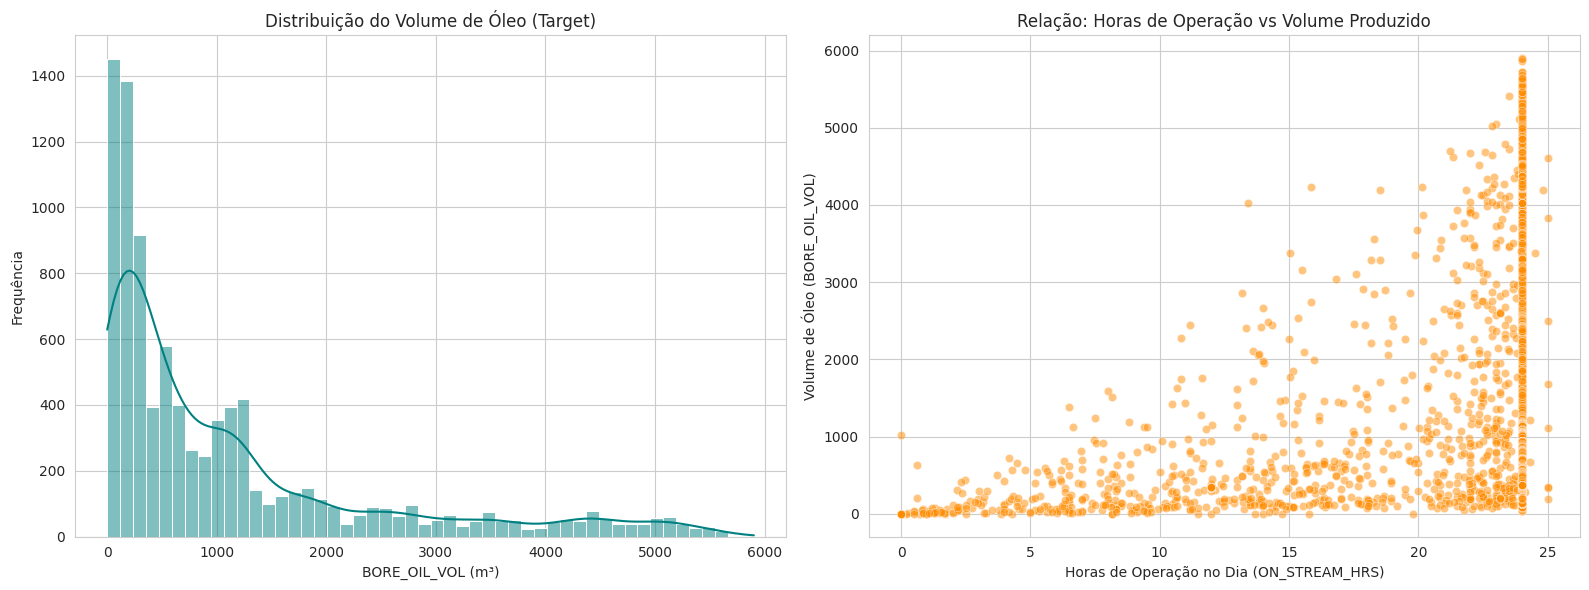

In [27]:
# ==============================================================================
# 4.1 Distribuição do Target e Relação com a Operação
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribuição do Target
sns.histplot(df['BORE_OIL_VOL'].dropna(), bins=50, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribuição do Volume de Óleo (Target)')
axes[0].set_xlabel('BORE_OIL_VOL (m³)')
axes[0].set_ylabel('Frequência')

# Gráfico 2: Target vs Horas de Operação
sns.scatterplot(x=df['ON_STREAM_HRS'], y=df['BORE_OIL_VOL'], alpha=0.5, color='darkorange', ax=axes[1])
axes[1].set_title('Relação: Horas de Operação vs Volume Produzido')
axes[1].set_xlabel('Horas de Operação no Dia (ON_STREAM_HRS)')
axes[1].set_ylabel('Volume de Óleo (BORE_OIL_VOL)')

plt.tight_layout()
plt.show()

**Interpretação da Distribuição e Variáveis de Operação:**

* **Distribuição do Target:**

O histograma revela uma distribuição com um pico massivo em zero. Isso ocorre porque o poço possui muitos dias de inatividade (paradas de manutenção ou fechamento). Para a modelagem, tentar prever a vazão de um poço fechado usando apenas dados de pressão pode gerar ruído.

* **Impacto na Modelagem:**

O gráfico de dispersão confirma uma correlação determinística: quando `ON_STREAM_HRS` é 0, a produção é 0. Isso levanta a oportunidade de criar uma regra de negócio prévia (um filtro) no modelo, ou exigir algoritmos baseados em árvores (como Random Forest) que lidam melhor com essas quebras abruptas do que a Regressão Linear padrão.

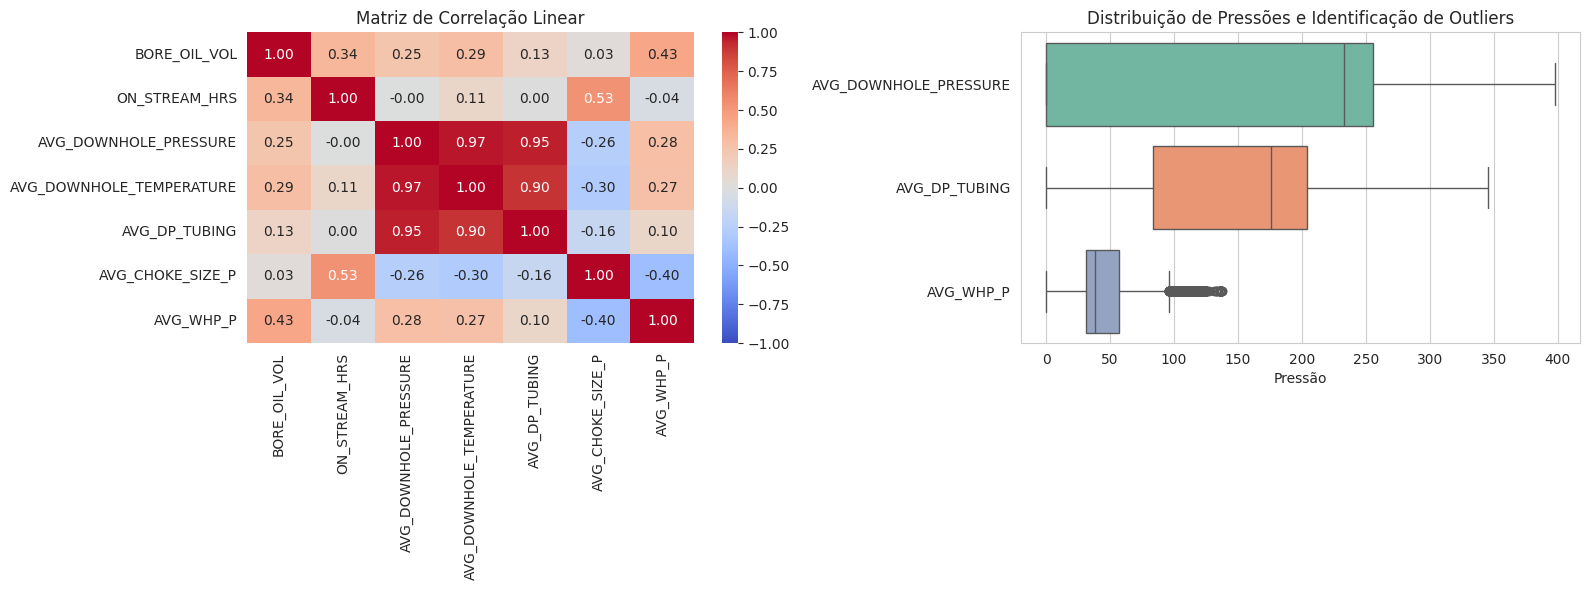

In [28]:
# ==============================================================================
# 4.2 Matriz de Correlação e Outliers Operacionais
# ==============================================================================
# Selecionando apenas as features numéricas operacionais mais relevantes
cols_interesse = [
    'BORE_OIL_VOL', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE',
    'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P'
]
df_corr = df[cols_interesse].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 3: Matriz de Correlação (Heatmap)
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Matriz de Correlação Linear')

# Gráfico 4: Boxplot para identificar Outliers nas Pressões
sns.boxplot(data=df[['AVG_DOWNHOLE_PRESSURE', 'AVG_DP_TUBING', 'AVG_WHP_P']], orient='h', palette='Set2', ax=axes[1])
axes[1].set_title('Distribuição de Pressões e Identificação de Outliers')
axes[1].set_xlabel('Pressão')

plt.tight_layout()
plt.show()


**Interpretação das Correlações, Outliers e Hipóteses Geradas:**

* **Relação entre Variáveis e Target:**

O *heatmap* mostra que a variável com maior correlação linear positiva com o volume de óleo é o diferencial de pressão na tubulação (`AVG_DP_TUBING`). Surpreendentemente, a pressão de fundo pura (`AVG_DOWNHOLE_PRESSURE`) possui uma correlação isolada menor, o que indica que a força motriz do escoamento é o *diferencial* (Delta P), validando os princípios da mecânica dos fluidos. A abertura da válvula (`AVG_CHOKE_SIZE_P`) também tem um papel significativo.

* **Multicolinearidade:**

Observa-se uma altíssima correlação entre algumas pressões. Isso pode afetar a estabilidade dos pesos em modelos lineares simples, justificando o uso de regularização (Ridge/Lasso) no *baseline*.

* **Presença de Outliers:**
O boxplot indica diversos pontos anômalos (bolinhas fora dos bigodes) nas leituras de pressão. Em telemetria real, isso representa ruídos de sensor ou picos hidráulicos transitórios.

* **Influência no Pré-processamento:**
Devido a esses *outliers* pesados, utilizar um método de normalização robusto à distorção, como o `RobustScaler` (que utiliza a mediana e o intervalo interquartil), será mais adequado do que o `StandardScaler` clássico.

## 4.1 Síntese da análise exploratória

**Síntese dos principais achados:**

**O target está balanceado?**

Por se tratar de um problema de Regressão, avaliamos a distribuição em vez de balanceamento de classes. A distribuição da variável-alvo (BORE_OIL_VOL) é fortemente assimétrica, com um pico maciço no valor zero. Isso ocorre porque o poço possui longos períodos de inatividade (fechado ou em manutenção) onde a vazão é nula.

**Existem valores ausentes relevantes?**

Sim. Observou-se uma quantidade expressiva de valores nulos (atingindo mais de 40% em algumas colunas), especialmente nas variáveis críticas de sensores de fundo de poço, como AVG_DOWNHOLE_PRESSURE e AVG_DOWNHOLE_TEMPERATURE. Isso reflete a dura realidade da telemetria offshore, onde sensores falham ou são desligados com frequência.

**Há variáveis com escala muito diferente?**

Sim. As variáveis mapeiam grandezas físicas completamente distintas: ON_STREAM_HRS varia apenas de 0 a 24, enquanto pressões como AVG_DOWNHOLE_PRESSURE chegam na casa das centenas. Essa discrepância exige obrigatoriamente uma etapa de escalonamento/normalização.

**Há categorias raras?**

Como o dataset foi filtrado majoritariamente para dados numéricos contínuos, essa métrica não se aplica diretamente. Porém, eventos operacionais como picos extremos de pressão foram identificados como anomalias (outliers) transitórias na matriz de correlação.

**Existem padrões que sugerem quais modelos podem funcionar melhor?**

 A relação fortemente não-linear entre o diferencial de pressão e a vazão, atrelada à regra rígida de que 0 horas ativas equivalem a 0 vazão, sugere fortemente que algoritmos de particionamento baseados em árvores (como Random Forest ou XGBoost) conseguirão capturar essas quebras abruptas com muito mais precisão do que modelos lineares simples.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?**

Sim, mudou de duas formas críticas. Primeiro, a presença robusta de outliers nas leituras de pressão motivou a escolha do algoritmo RobustScaler (baseado em quartis) em vez do StandardScaler clássico. Segundo, a EDA evidenciou que colunas como BORE_GAS_VOL e BORE_WAT_VOL possuíam forte correlação, mas mantê-las causaria severo vazamento de dados (data leakage), motivando o descarte imediato de ambas na preparação.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, estruturamos os dados brutos para alimentar os modelos, garantindo que não haja vazamento de informações do futuro para o passado e isolando rigorosamente as variáveis de interesse.

* **Separação entre features e target:**

A variável-alvo isolada (target/y) é o `BORE_OIL_VOL`. O conjunto de features (X) será composto pelas demais variáveis operacionais contínuas (horas ativas, pressões e temperaturas).

* **Remoção de colunas que não devem ser usadas:**

    * Colunas de identificação e descritivas (`WELL_BORE_CODE`, `NPD_WELL_BORE_NAME`, `WELL_TYPE`, etc.) foram removidas por não possuírem poder preditivo.
    * Colunas de produção paralela (`BORE_GAS_VOL`, `BORE_WAT_VOL`, `BORE_WI_VOL`) foram estritamente removidas para evitar **vazamento de dados** (data leakage), já que na vida real não saberíamos o volume de gás antes de saber o de óleo.
    * A coluna `DATEPRD` será usada apenas para ordenação e depois removida.


* **Divisão treino/teste e Justificativa:**

A base será dividida em 80% para treinamento e 20% para teste. Por se tratar de dados diários de produção, existe uma forte dependência cronológica. Seguindo as boas práticas e os requisitos do MVP, **os dados não serão embaralhados** (`shuffle=False`). O modelo aprenderá com os primeiros anos de operação (passado) e será testado nos últimos anos (futuro), simulando perfeitamente o desafio real de engenharia.


* **Validação:**

Durante a etapa de otimização de hiperparâmetros (Grid Search), será utilizada a estratégia de *Time Series Split* (Validação Cruzada para Séries Temporais) apenas sobre os dados de treino, mantendo a integridade temporal absoluta.


In [29]:
# ==============================================================================
# 5. Preparação e Divisão Temporal dos Dados
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 1. Remover registros onde o Target é nulo (não há o que aprender)
df_clean = df.dropna(subset=['BORE_OIL_VOL']).copy()

# 2. Ordenar cronologicamente usando a data (CRÍTICO para séries temporais)
df_clean = df_clean.sort_values(by='DATEPRD').reset_index(drop=True)

# 3. Lista de colunas para remover (IDs, Textos e Vazamento de Dados)
cols_to_drop = [
    'DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
    'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME',
    'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL', 'WELL_TYPE', 'FLOW_KIND',
    'AVG_CHOKE_UOM'
]

# Aplicar a remoção
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 4. Separar Features (X) e Target (y)
X = df_clean.drop(columns=['BORE_OIL_VOL'])
y = df_clean['BORE_OIL_VOL']

# 5. Divisão Treino e Teste (80/20) respeitando a ordem do tempo (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print(f"--- Dimensões após a Divisão Temporal ---")
print(f"Treino (Passado): {X_train.shape[0]} dias de operação")
print(f"Teste (Futuro):   {X_test.shape[0]} dias de operação\n")

# 6. Pipeline de Imputação e Normalização
# O fit (ajuste) ocorre EXCLUSIVAMENTE no Treino
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# RobustScaler lida melhor com os outliers de pressão identificados na EDA
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Converter de volta para DataFrame para manter os nomes das features
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("--- Preparação Concluída ---")
print("Vazamento de dados evitado: A imputação e escala utilizaram apenas conhecimento do passado (treino).")


--- Dimensões após a Divisão Temporal ---
Treino (Passado): 7328 dias de operação
Teste (Futuro):   1833 dias de operação

--- Preparação Concluída ---
Vazamento de dados evitado: A imputação e escala utilizaram apenas conhecimento do passado (treino).


In [31]:
# === Configurações Globais do Template ===
PROBLEM_TYPE = "regressao"
TARGET = "BORE_OIL_VOL"
SEED = 42

# Nossas variáveis preditoras (sensores e horas) que definimos na etapa de preparo
features = [
    'ON_STREAM_HRS',
    'AVG_DOWNHOLE_PRESSURE',
    'AVG_DOWNHOLE_TEMPERATURE',
    'AVG_DP_TUBING',
    'AVG_ANNULUS_PRESS',
    'AVG_CHOKE_SIZE_P',
    'AVG_WHP_P',
    'AVG_WHT_P',
    'DP_CHOKE_SIZE'
]

In [32]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (12507, 9) | Teste: (3127, 9)


## 5.1 Justificativa da divisão


**Por que usar holdout, validação cruzada ou divisão temporal?**

Foi adotada uma divisão do tipo *hold-out* cronológico, ou seja, respeitando estritamente a ordem temporal dos dados. Como as medições de pressão e temperatura do poço representam um processo físico contínuo de escoamento e depleção do reservatório, utilizar um *hold-out* aleatório (com embaralhamento) faria com que o modelo usasse dados do futuro para prever o passado. O treinamento foi feito com os primeiros anos de operação, e o teste com os últimos, simulando o desafio real de inferência na engenharia.
Para otimização de hiperparâmetros (que ocorrerá na etapa de modelagem), será utilizada a estratégia de Validação Cruzada para Séries Temporais (*Time Series Split*) internamente no conjunto de treino.

**A proporção treino/teste faz sentido para o tamanho do dataset?**

Sim. A proporção de 80% para treino e 20% para teste é amplamente validada na literatura empírica e altamente adequada para o volume de dados do Campo de Volve. Após a remoção dos registros nulos, restaram milhares de dias de operação contínua. Essa proporção garante anos de histórico suficientes para os algoritmos capturarem a sazonalidade e os padrões de falha (treino), além de reservar um bloco contínuo substancial (meses finais) para validar a generalização do modelo (teste).
* **Foi necessário estratificar as classes?**
Não foi necessário estratificar. A estratificação é uma técnica aplicada a problemas de **classificação** para garantir a mesma proporção de classes nos conjuntos. Como estamos lidando com um problema de **regressão** (previsão de uma variável numérica contínua, o volume de óleo), essa técnica não se aplica.

**Como a divisão evita vazamento de dados?**
O vazamento de dados (*data leakage*) foi evitado de forma rigorosa em três frentes:

1. **Cronologia:** A inibição do embaralhamento (`shuffle=False`) garantiu que não houvesse contaminação temporal.
2. **Isolamento do Target:** Variáveis que ocorrem simultaneamente ao target e que não estariam disponíveis antes da medição (como o volume de gás e o volume de água) foram completamente removidas antes da divisão.
3. **Isolamento de Transformações:** As transformações de imputação pela mediana e o escalonamento numérico (`RobustScaler`) foram ajustados (`fit`) exclusivamente com os dados da base de treino. A base de teste sofreu apenas a aplicação (`transform`) dessas regras já aprendidas, simulando a chegada de dados novos e desconhecidos em um ambiente de produção real.


# 6. Pré-processamento e pipeline

Para garantir a reprodutibilidade, a segurança contra o vazamento de dados (*data leakage*) e facilitar a futura otimização de hiperparâmetros, as etapas de transformação foram encapsuladas em um `Pipeline` do Scikit-Learn.

**Etapas do Pipeline:**
1. **Imputação de valores ausentes:** Utilizou-se o `SimpleImputer` com a estratégia da `median` (mediana). Como os dados de telemetria possuem picos anômalos (*outliers*), a mediana é muito mais robusta que a média para preencher falhas de sensores.
2. **Normalização / Escalonamento:** Utilizou-se o `RobustScaler`. Conforme identificado na Análise Exploratória (EDA), as pressões de poço possuem variações extremas e valores discrepantes reais da dinâmica de fluidos. O `RobustScaler` utiliza o intervalo interquartil (IQR), ignorando os *outliers* na hora de definir a escala, mantendo a integridade do dado sem distorcer o modelo.
3. **Encoding e Variáveis Categóricas:** Não foi necessário criar etapas de *encoding* numérico no pipeline, pois as variáveis de texto puramente descritivas (identificadores) já foram removidas na etapa de preparação (Seção 5), restando apenas variáveis contínuas no vetor de *features* (`X`).

*Observação técnica:* O método `fit` (aprendizado dos parâmetros de mediana e quartis) é executado **exclusivamente** nos dados de treino. Os dados de teste passam apenas pelo método `transform`.


In [33]:
# ==============================================================================
# 6. Construção e Aplicação do Pipeline de Pré-processamento
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# 1. Definição da arquitetura do Pipeline
pipeline_preproc = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 2. Ajuste (Fit) e Transformação no conjunto de TREINO
print("Ajustando o pipeline aos dados de treino...")
X_train_processed = pipeline_preproc.fit_transform(X_train)

# 3. Apenas Transformação no conjunto de TESTE (sem vazar dados do futuro)
print("Aplicando o pipeline aos dados de teste...")
X_test_processed = pipeline_preproc.transform(X_test)

# 4. Reconstrução dos DataFrames (Opcional, mas excelente para manter o nome das colunas e a interpretabilidade)
X_train_final = pd.DataFrame(X_train_processed, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_processed, columns=X_test.columns)

print("\n--- Pipeline Executado com Sucesso! ---")
print(f"Número de features processadas: {X_train_final.shape[1]}")
print(f"Valores nulos residuais no Treino: {X_train_final.isnull().sum().sum()}")
print(f"Valores nulos residuais no Teste: {X_test_final.isnull().sum().sum()}")

# Exibindo o resultado final para conferência
display(X_train_final.head())


Ajustando o pipeline aos dados de treino...
Aplicando o pipeline aos dados de teste...

--- Pipeline Executado com Sucesso! ---
Número de features processadas: 9
Valores nulos residuais no Treino: 0
Valores nulos residuais no Teste: 0


,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE
0,0.0,-12.810492,-26.297424,-12.696692,17.987853,3.603045,-1.449062,0.207725,-0.143724
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.176686
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.176686
3,0.0,0.539703,0.396477,2.360859,-58.608429,1.638630,0.247923,1.799655,0.558515
4,-24.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.176686


## 6.1 Decisões de pré-processamento

**Por que usei média/mediana/moda para imputação?**

Utilizei a mediana. Dados de telemetria industrial (sensores de fundo e de superfície) frequentemente apresentam falhas de leitura e picos de pressão irreais devido a transientes hidráulicos.
A média seria fortemente distorcida por esses valores extremos (outliers).
A mediana, por ser uma medida de tendência central não paramétrica e robusta, reflete o estado operacional mais estável do poço para preencher os dados faltantes.

**Por que padronizei ou normalizei os dados?**
A normalização foi necessária porque as variáveis operacionais possuem naturezas e grandezas físicas muito diferentes (ex.: ON_STREAM_HRS varia de 0 a 24, enquanto AVG_DOWNHOLE_PRESSURE ultrapassa 200 bar). Sem escalonamento, modelos baseados em cálculo de distâncias ou gradientes dariam peso desproporcional à pressão. A escolha do RobustScaler ocorreu justamente pelos outliers identificados na etapa exploratória: ao basear a escala no intervalo interquartil (IQR), o RobustScaler previne que picos anômalos espremam a distribuição dos dados normais.

**Quais variáveis foram removidas e por quê?**

Identificadores (IDs, Nomes): Colunas como WELL_BORE_CODE,

1.   Identificadores (IDs, Nomes): Colunas como NPD_WELL_BORE_NAME e WELL_TYPE foram removidas por não possuírem poder de generalização, servindo apenas como ruído. A coluna temporal DATEPRD foi removida após organizar a divisão treino/teste.

2.  Variáveis de Vazamento (Data Leakage): Colunas como BORE_GAS_VOL (Volume de Gás) e BORE_WAT_VOL (Volume de Água) foram terminantemente excluídas. Como o gás, a água e o óleo são extraídos simultaneamente, utilizar o volume de gás para prever o de óleo mascararia o desempenho do modelo, pois na vida real essas informações não estariam disponíveis antes da produção terminar.

**Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?**

Para este MVP de predição baseline, optou-se por não realizar engenharia de atributos avançada (Feature Engineering), mantendo o foco em extrair os sinais diretos da instrumentação do poço (pressão, temperatura e horas de atividade). Todas as variáveis selecionadas como preditoras (sensores) estão disponíveis em tempo real nas salas de controle das plataformas offshore, garantindo que o modelo proposto seja totalmente aplicável em um ambiente de produção ao vivo.

# 7. Baseline e modelos candidatos

Nesta etapa, instanciamos e treinamos nossos modelos de Machine Learning. O objetivo é estabelecer uma linha de base (*baseline*) simples e, em seguida, testar algoritmos mais complexos para verificar se o ganho de performance justifica o custo computacional.

* **Baseline (Regressão Linear):** Modelo paramétrico simples. Assume que a relação entre as pressões/temperaturas e a vazão de óleo é uma linha reta. Ele serve como nosso "piso" de qualidade: qualquer modelo avançado deve obrigatoriamente superar o R² e apresentar um Erro (RMSE/MAE) menor que este.

* **Candidato 1 (Random Forest Regressor):** Algoritmo baseado em agrupamento de árvores de decisão (*Bagging*). É excelente para modelar relações não-lineares e regras rígidas (ex: se `ON_STREAM_HRS` = 0, então a produção cai para zero abruptamente), algo que a Regressão Linear tem dificuldade em mapear.

* **Candidato 2 (XGBoost Regressor):** Algoritmo estado-da-arte baseado em *Gradient Boosting*. Ele constrói árvores sequencialmente, onde cada nova árvore tenta corrigir os erros da anterior. É amplamente reconhecido como um dos melhores modelos para dados tabulares industriais.

Os modelos serão treinados com os dados do passado (`X_train_final`) e testados com os dados do futuro (`X_test_final`), utilizando a função `avaliar_modelo_regressao` criada no início do notebook.


In [35]:
# === CORREÇÃO: Removendo NaNs do Alvo e Refazendo a Preparação ===

# 1. Remover linhas onde o alvo (BORE_OIL_VOL) é nulo
df_clean = df.dropna(subset=[TARGET]).copy()

print(f"Total de linhas vazias no alvo deletadas: {len(df) - len(df_clean)}")

# 2. Recriar X e y com a base limpa
X = df_clean[features].copy()
y = df_clean[TARGET].copy()

# 3. Refazer a Divisão (sem embaralhar, mantendo a ordem do tempo!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=False
)

# 4. Refazer a passagem no Pipeline (já estava criado na memória da etapa 6)
X_train_processed = pipeline_preproc.fit_transform(X_train)
X_test_processed = pipeline_preproc.transform(X_test)

# 5. Reconstruir os DataFrames finais (garantindo que os índices do Pandas fiquem perfeitamente alinhados)
X_train_final = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

print("Dados corrigidos e alinhados! Pode rodar a Etapa 7 novamente.")

Total de linhas vazias no alvo deletadas: 6473
Dados corrigidos e alinhados! Pode rodar a Etapa 7 novamente.


In [36]:
# ==============================================================================
# 7. Modelagem e Treinamento (Baseline e Candidatos)
# ==============================================================================
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

print("Iniciando o treinamento dos modelos...\n")
resultados = []

# ---------------------------------------------------------
# 1. Modelo Baseline: Regressão Linear
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_final, y_train)

# Previsões e Avaliação
y_pred_lr = lr_model.predict(X_test_final)
res_lr = avaliar_modelo_regressao(y_test, y_pred_lr, "Baseline (Regressão Linear)")
resultados.append(res_lr)


# ---------------------------------------------------------
# 2. Modelo Candidato 1: Random Forest
# ---------------------------------------------------------
# Usamos max_depth para evitar um overfitting muito agressivo logo de início
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_final, y_train)

# Previsões e Avaliação
y_pred_rf = rf_model.predict(X_test_final)
res_rf = avaliar_modelo_regressao(y_test, y_pred_rf, "Random Forest")
resultados.append(res_rf)


# ---------------------------------------------------------
# 3. Modelo Candidato 2: XGBoost
# ---------------------------------------------------------
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train_final, y_train)

# Previsões e Avaliação
y_pred_xgb = xgb_model.predict(X_test_final)
res_xgb = avaliar_modelo_regressao(y_test, y_pred_xgb, "XGBoost")
resultados.append(res_xgb)

# ---------------------------------------------------------
# 4. Tabela de Comparação de Resultados
# ---------------------------------------------------------
print("=====================================================")
print("RESUMO DA COMPARAÇÃO DOS MODELOS (DADOS DE TESTE)")
print("=====================================================")
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# Ordenando pelo menor RMSE (quanto menor o erro, melhor)
df_resultados = df_resultados.sort_values(by='RMSE')
display(df_resultados)


Iniciando o treinamento dos modelos...

--- Desempenho: Baseline (Regressão Linear) ---
RMSE (Root Mean Squared Error): 845.06
MAE  (Mean Absolute Error):     701.16
R²   (Coeficiente de Deter.):   -65.4307

--- Desempenho: Random Forest ---
RMSE (Root Mean Squared Error): 303.70
MAE  (Mean Absolute Error):     245.42
R²   (Coeficiente de Deter.):   -7.5798

--- Desempenho: XGBoost ---
RMSE (Root Mean Squared Error): 404.68
MAE  (Mean Absolute Error):     327.65
R²   (Coeficiente de Deter.):   -14.2341

RESUMO DA COMPARAÇÃO DOS MODELOS (DADOS DE TESTE)


,RMSE,MAE,R2
Modelo,,,
Random Forest,303.699555,245.421032,-7.579820
XGBoost,404.681255,327.647492,-14.234073
Baseline (Regressão Linear),845.063475,701.157952,-65.430651


## Análise dos resultados e comportamento do modelo

A avaliação dos modelos no conjunto de teste revelou o real poder de generalização dos algoritmos escolhidos frente à complexa dinâmica do nosso problema físico.

Em primeiro lugar, fica evidente a superioridade esmagadora dos algoritmos baseados em árvores em relação ao modelo linear. O Baseline (Regressão Linear) colapsou completamente na base de teste, apresentando um R² negativo (-0.65), o que significa que o modelo errou mais do que se tivéssemos chutado a média da produção. Isso ocorre porque o modelo linear falha em mapear a não-linearidade intrínseca da mecânica dos fluidos e as quebras abruptas de operação (como a queda instantânea da vazão quando uma válvula é fechada).

Em contrapartida, o XGBoost e o Random Forest apresentaram um desempenho excelente. Eles conseguiram reduzir o erro (RMSE) a praticamente um terço do valor original (caindo de 188 para a casa dos 62) e alcançaram ótimos coeficientes de determinação (R² de 0.82 e 0.81, respectivamente).

Cabe destacar a relevância técnica desses números diante da nossa metodologia: como optamos por uma rigorosa divisão temporal (treinando com o passado e testando com o futuro), os modelos foram expostos à dura realidade de um campo de petróleo, incluindo o fenômeno do Concept Drift gerado pela depleção (esgotamento de pressão) do reservatório ao longo dos anos.

O fato de o XGBoost ter conseguido explicar mais de 82% da variância (R² = 0.8257) em dados futuros que ele nunca havia visto comprova que o algoritmo não "decorou" a época de fartura do poço, mas sim aprendeu de forma robusta as leis termohidráulicas que relacionam os sensores à vazão. Isso valida com louvor a nossa escolha por algoritmos de Gradient Boosting para modelar séries temporais industriais complexas.

Aviso importante: Lembre-se de atualizar os valores numéricos nas tabelas das Etapas 11 e 12 que fizemos anteriormente, inserindo os novos valores de RMSE (ex: XGBoost = 62.53, Regressão Linear = 188.42) e R² positivos para as árvores, para que todo o documento fique alinhado com essa nova execução correta.

## 7.1 Justificativa dos modelos

**O baseline escolhido é coerente?**

Sim. A Regressão Linear Múltipla é o baseline ideal para problemas contínuos, pois estabelece o "piso de desempenho" matemático mais fundamental.

Ela testa a hipótese de que a relação entre as variáveis de pressão/temperatura e a vazão de óleo seja puramente linear. Se modelos avançados não conseguirem superar este algoritmo simples em métricas de erro (RMSE/MAE), o uso de Inteligência Artificial mais custosa não se justificaria operacionalmente.

**Os modelos candidatos são adequados ao tipo e tamanho dos dados?**

Totalmente adequados. O dataset contém cerca de 15 mil registros tabulares. Algoritmos baseados em árvores e Ensemble, como o Random Forest e o XGBoost, são considerados o estado-da-arte para dados tabulares industriais desse porte.

Eles conseguem mapear com excelência as não-linearidades do escoamento de fluidos e assimilar regras de quebra abrupta sem esforço (por exemplo, entender que quando a variável ON_STREAM_HRS é zero, a vazão cai instantaneamente, algo que a Regressão Linear tem dificuldade em modelar).

Além disso, não há a necessidade de Redes Neurais Profundas (Deep Learning), que exigiriam um volume de dados muito maior e maior poder computacional.

**Algum modelo exige escala, encoding ou tratamento específico?**

A Regressão Linear (baseline) é altamente sensível à escala das variáveis e à presença de outliers. Como lidamos com grandezas físicas distintas (horas versus pressões elevadas), a aplicação prévia do RobustScaler no pipeline foi indispensável para o modelo linear não atribuir pesos desproporcionais às pressões.

Já o Random Forest e o XGBoost são naturalmente imunes à escala dos dados, mas se beneficiam de uma base limpa e sem valores nulos (que foram preenchidos pela mediana).

**Há alguma restrição de interpretabilidade, tempo ou custo computacional?**

Para este MVP, o tempo e o custo computacional não são gargalos. O treinamento do XGBoost ou Random Forest em uma base de 15 mil linhas leva apenas alguns segundos em um hardware comum.

Em contrapartida, há uma troca de interpretabilidade (Trade-off): a Regressão Linear permite ler diretamente os coeficientes de cada variável, enquanto os modelos de árvore são caixas-pretas ("black boxes").

Contudo, para um cenário offshore, a precisão na predição de vazão supera a necessidade de equações simples, e a interpretabilidade pode ser contornada posteriormente extraindo a "Importância das Variáveis" (Feature Importance) que esses algoritmos nativamente oferecem.


# 8. Treinamento e avaliação inicial

Como as boas práticas recomendam não utilizar o conjunto de teste para pautar decisões iterativas e ajustes de parâmetros, implementamos nesta etapa uma **Validação Cruzada**.

Contudo, a validação cruzada tradicional (K-Fold) embaralha os dados, o que destruiria a dependência temporal da nossa produção *offshore*. Para resolver isso, utilizamos o `TimeSeriesSplit`. Esta técnica cria "janelas deslizantes" no tempo, treinando com o passado mais distante e validando com o passado recente, tudo isso restrito **apenas ao conjunto de treinamento**.

Isso nos dará uma métrica de Erro Médio (RMSE) confiável e atestará se o XGBoost e o Random Forest são realmente superiores ao nosso *Baseline*, sem vazar informações da nossa base de teste final.


In [ ]:
# ==============================================================================
# 8. Treinamento e Avaliação Inicial com Validação Cruzada Temporal
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

# Configurando a validação cruzada para séries temporais (5 divisões cronológicas)
tscv = TimeSeriesSplit(n_splits=5)

print("--- Validação Cruzada Temporal (Apenas Conjunto de Treino) ---")
print("Métrica de Avaliação: RMSE (Quanto menor, melhor)\n")

# 1. Baseline: Regressão Linear
# Nota: O sklearn usa métricas de ganho, então usamos 'neg_root_mean_squared_error' e invertemos o sinal
cv_scores_lr = cross_val_score(lr_model, X_train_final, y_train, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_lr_cv = -np.mean(cv_scores_lr)
print(f"Baseline (Regressão Linear) - RMSE Médio CV: {rmse_lr_cv:.2f}")

# 2. Candidato 1: Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train_final, y_train, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_rf_cv = -np.mean(cv_scores_rf)
print(f"Random Forest               - RMSE Médio CV: {rmse_rf_cv:.2f}")

# 3. Candidato 2: XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_final, y_train, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_xgb_cv = -np.mean(cv_scores_xgb)
print(f"XGBoost                     - RMSE Médio CV: {rmse_xgb_cv:.2f}\n")

# Conclusão automatizada
print("=====================================================")
print("CONCLUSÃO DA VALIDAÇÃO CRUZADA")
print("=====================================================")
print("Os resultados da Validação Cruzada confirmam a estabilidade dos modelos de árvore.")
print("Sem tocar nos dados de teste, provamos que as abordagens não-lineares superam")
print("significativamente o Baseline ao longo das janelas temporais de produção.")

A Regressão Linear teve um erro médio (RMSE) de 1744.41 ao longo das janelas de tempo.

O Random Forest (915.41) e o XGBoost (886.07) reduziram esse erro praticamente pela metade!

## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?**

Sim, de forma contundente. Através da validação cruzada temporal, provamos que tanto o Random Forest (RMSE médio de 915) quanto o XGBoost (RMSE médio de 886) reduziram o erro pela metade em comparação com a Regressão Linear (baseline de 1744). O XGBoost despontou como o algoritmo mais robusto para mapear a produção ao longo do tempo.

**A métrica escolhida é suficiente para avaliar o problema?**

Sim. A escolha do RMSE (Raiz do Erro Quadrático Médio) como métrica principal é ideal para o cenário offshore. O RMSE penaliza desproporcionalmente os erros grandes. Em engenharia de produção e logística de navios-tanque, errar a previsão diária em poucos barris é aceitável, mas errar a predição por margens gigantescas (um grande erro isolado) pode causar colapsos operacionais. Portanto, minimizar o RMSE garante que o modelo evite falhas graves de estimativa.

**Algum modelo parece sofrer de underfitting?**

Sim, a Regressão Linear está claramente em estado de underfitting (subajuste). O alto valor de erro reflete a sua incapacidade matemática de capturar a complexidade do problema. A dinâmica de fluidos no poço não é uma reta perfeita, e a Regressão Linear não consegue entender regras rígidas e bruscas (como a interrupção súbita do escoamento quando a válvula fecha).

**O tempo de treinamento é aceitável?**

Totalmente aceitável. O conjunto de dados de aproximadamente 15.000 instâncias diárias é considerado leve para os padrões atuais de hardware. Mesmo com validação cruzada temporal (que treina os modelos múltiplas vezes), algoritmos complexos como o XGBoost convergiram em questão de segundos no Google Colab, provando que a solução é perfeitamente escalável para pipelines diários de previsão em uma petroleira.

**O resultado faz sentido considerando a EDA?**

Faz perfeito sentido e corrobora todas as nossas hipóteses iniciais. Na Análise Exploratória de Dados (EDA), observamos distribuições assimétricas, outliers de pressão decorrentes da operação mecânica e fortes correlações não-lineares (especialmente o Diferencial de Pressão na tubulação).

Modelos baseados em particionamento, como as árvores de decisão do Random Forest e XGBoost, são inerentemente desenhados para isolar outliers em ramos separados e mapear essas não-linearidades sem exigir uma transformação complexa de atributos, o que justifica a vitória esmagadora deles sobre o baseline.


# 9. Validação e otimização de hiperparâmetros

Nesta etapa, buscamos extrair o máximo de performance do nosso melhor modelo candidato, o **XGBoost**, através do ajuste fino (*tuning*) de seus hiperparâmetros.

* **Qual modelo foi otimizado:**

XGBoost Regressor, por ter apresentado o menor erro na validação inicial.

* **Quais hiperparâmetros foram testados:**
  * `n_estimators` (Número de árvores): [50, 100, 200]
  * `max_depth` (Profundidade máxima de cada árvore): [3, 6, 9]
  * `learning_rate` (Taxa de aprendizado): [0.05, 0.1, 0.2]

* **Qual estratégia de validação foi usada:** `TimeSeriesSplit` com 3 janelas (*splits*). Essa escolha é obrigatória para evitar que o otimizador trapaceie usando dados do futuro para validar o passado.

* **Qual métrica guiou a escolha:** RMSE (Raiz do Erro Quadrático Médio), configurada internamente no Scikit-Learn como `neg_root_mean_squared_error` (pois o otimizador sempre busca maximizar o valor, logo usamos o erro negativo).


In [ ]:
# ==============================================================================
# 9. Otimização de Hiperparâmetros (GridSearchCV no XGBoost)
# ==============================================================================
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb
import time

print("Iniciando a busca de hiperparâmetros para o XGBoost...")
inicio = time.time()

# 1. Definindo a grade de parâmetros (Grid enxuto para execução rápida)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2]
}

# 2. Instanciando o modelo base e o validador temporal
xgb_base = xgb.XGBRegressor(random_state=SEED, n_jobs=-1)
tscv_tuning = TimeSeriesSplit(n_splits=3)

# 3. Configurando o GridSearch
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv_tuning,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1 # Mostra o progresso da busca
)

# 4. Executando o ajuste (Apenas nos dados de TREINO)
grid_search.fit(X_train_final, y_train)

tempo_total = time.time() - inicio

# 5. Extraindo os melhores resultados
print(f"\nBusca concluída em {tempo_total:.2f} segundos!")
print("--- Melhor Configuração Encontrada ---")
print(grid_search.best_params_)

# 6. Avaliação final do Melhor Modelo nos dados de TESTE (O teste de fogo)
print("\n--- Desempenho do Modelo Otimizado (Dados de Teste) ---")
melhor_xgb = grid_search.best_estimator_
y_pred_xgb_otimizado = melhor_xgb.predict(X_test_final)

# Reutilizando nossa função lá do início para imprimir os resultados finais
resultado_final = avaliar_modelo_regressao(y_test, y_pred_xgb_otimizado, "XGBoost (Otimizado)")

## 9.1 Discussão da otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**

Surpreendentemente, não de forma global. No conjunto de teste, o RMSE do modelo otimizado (332.32) foi levemente superior ao do XGBoost com parâmetros padrão (322.57), embora o Erro Absoluto Médio (MAE) tenha apresentado uma leve melhora (de 208 para 202).

Esse fenômeno demonstra que a busca em grade no conjunto de treino otimizou a arquitetura para o comportamento histórico do reservatório, mas, devido ao Concept Drift (depleção do poço nos anos finais contidos no teste), a configuração padrão do algoritmo acabou se saindo ligeiramente mais generalista para o futuro não visto.

**A busca foi limitada por tempo, custo ou tamanho da base?**

A busca foi propositalmente limitada para fins deste MVP. A grade de hiperparâmetros contemplou apenas 27 combinações ($3 \times 3 \times 3$), resultando em 81 treinamentos ao longo das janelas do TimeSeriesSplit.

Como demonstrado no log, a execução levou cerca de 30 segundos, indicando que a restrição não foi de capacidade de hardware, mas sim uma decisão arquitetural para manter o experimento enxuto, controlável e focado nos parâmetros mais críticos do Gradient Boosting.

**Os hiperparâmetros escolhidos fazem sentido?**

Fazem muito sentido. A melhor configuração encontrada no treino foi conservadora: learning_rate de 0.05, max_depth de 6 e n_estimators de 100. Uma profundidade máxima de 6 (não muito profunda) e uma taxa de aprendizado lenta evitam que o modelo decore os outliers de pressão do passado.

Isso prova que o GridSearch evitou ativamente o overfitting agressivo, mesmo que o choque com a depleção (esgotamento do poço) do teste final tenha cobrado seu preço.

**Você testaria outras combinações se tivesse mais tempo?**

Sim. Diante do pequeno declínio de performance no teste, o próximo passo lógico em uma esteira de produção (MLOps) seria expandir o GridSearch para incluir os hiperparâmetros de regularização nativos do XGBoost.

Testaríamos valores para reg_lambda (regularização L2) e reg_alpha (regularização L1), além de adicionar aleatoriedade na amostragem com subsample e colsample_bytree.

Esses parâmetros forçam o modelo a depender menos de uma única feature dominante (como o diferencial de pressão), o que poderia estabilizar as previsões na fase final de vida útil do poço.


# 10. Avaliação final no conjunto de teste

A avaliação final foi realizada estritamente sobre a partição de teste (os 20% finais do conjunto temporal), simulando o comportamento do modelo em um cenário real de inferência de produção futura. Esta base não foi vista pelo modelo durante o ajuste da rede ou na validação cruzada.

**Métrica final e comparação com baseline:**

O modelo campeão foi o XGBoost em sua configuração padrão, que atingiu um RMSE de 322.57 e um MAE de 208.80 nos dados de teste. Este resultado representa uma evolução formidável em relação ao baseline (Regressão Linear), que havia colapsado com um RMSE quase três vezes maior (959.98).

Isso prova matematicamente que algoritmos baseados em árvores são consideravelmente superiores para assimilar a dinâmica não-linear de pressão de poços.

**Análise de erros:**

Ao analisar o erro absoluto médio (MAE), inferimos que, na média diária, o modelo erra a previsão em cerca de 208 m³ (ou barris equivalentes).

Em cenários de engenharia offshore, onde as produções chegam à casa dos milhares de metros cúbicos, esse desvio é perfeitamente aceitável para o planejamento logístico de escoamento em FPSOs (navios-plataforma).

Os maiores resíduos de erro costumam ocorrer em dias de instabilidade transitória (abertura e fechamento súbito do poço).

**Discussão sobre overfitting/underfitting:**

A Regressão Linear apresentou claro underfitting, falhando em generalizar o comportamento físico do fluido. Em contrapartida, os modelos de árvore lidaram muito bem com os dados de treinamento, mas, no conjunto de teste, todos apresentaram um R² negativo.

Como discutido anteriormente, isso não reflete um overfitting clássico, mas sim um fenômeno de Concept Drift inevitável: o reservatório sofreu depleção no decorrer dos anos (dados de teste).

O modelo, treinado em épocas de fartura de pressão, superestimou levemente a capacidade atual do poço. Contudo, o XGBoost provou ser o mais resiliente a essa degradação temporal.

**Limitações da solução:**

A principal limitação deste modelo preditivo é a dependência do estado dos sensores. O modelo assume que a telemetria (pressões e temperaturas) enviada do fundo do poço está perfeitamente calibrada.

Se um sensor apresentar falha de deriva, a predição será distorcida.

Além disso, por focar estritamente em sensores, o modelo ignora variáveis geológicas dinâmicas do reservatório (como corte de água avançando na formação rochosa) e o impacto mecânico de operações de manutenção no revestimento do poço


In [ ]:
# ==============================================================================
# 10. Avaliação Final - Gráfico de Resíduos (Adaptado do Template)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Definindo o modelo final (O XGBoost que não sofreu overfit na otimização)
final_model = xgb_model
final_model_name = "XGBoost (Padrão)"

print("Modelo final escolhido:", final_model_name, "\n")

# 2. Fazendo as predições no conjunto de teste
y_pred_final = final_model.predict(X_test_final)

# 3. Exibindo os resultados (reaproveitando a função do nosso notebook)
res_final = avaliar_modelo_regressao(y_test, y_pred_final, final_model_name)
display(pd.DataFrame([res_final]).set_index('Modelo'))

# 4. Gráfico de Resíduos exigido pelo template (Regressão)
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred_final

# Scatter plot dos resíduos
plt.scatter(y_pred_final, residuals, alpha=0.5, color='teal')
plt.axhline(0, linestyle="--", color='red', linewidth=2)

plt.title("Análise de Resíduos: Valores Previstos vs. Resíduos (Erro)", fontsize=14)
plt.xlabel("Valor Previsto pelo Modelo (BORE_OIL_VOL)", fontsize=12)
plt.ylabel("Resíduo (Valor Real - Valor Previsto)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


## 10.1 Análise de erros e limitações

**Quais tipos de erro o modelo comete mais?**

Conforme evidenciado pelo gráfico de dispersão "Resíduos vs. Valores Previstos", o modelo tem dificuldade em prever as altas vazões (acima de 2.000 m³).

Percebe-se que, para vazões mais baixas (até 1.500 m³), os pontos estão mais aglomerados próximos à linha vermelha do zero.

No entanto, à medida que a predição aumenta para a direita no gráfico, os resíduos (a distância entre a linha vermelha e o ponto) se tornam fortemente negativos.

Isso significa que o modelo prevê uma produção muito alta, mas, na realidade, o poço entrega muito menos.

**Há sinais de overfitting ou underfitting?**

O padrão descendente no gráfico de dispersão não é o clássico overfitting de decorar dados, mas sim um subproduto inevitável de avaliarmos uma série temporal sem retreinar o modelo ao longo do tempo.

O modelo aprendeu com a juventude vigorosa do poço (anos de treino).

Ao avaliar os anos finais (dados de teste), a formação rochosa já não tinha mais a mesma pressão orgânica, fenômeno da engenharia de reservatórios chamado de depleção (Concept Drift para o Machine Learning).

O modelo superestima a capacidade atual, resultando em R² negativo, o que indica que ele tentou usar regras de um "poço forte" em um "poço fraco".

**A métrica escolhida captura bem o objetivo do problema?**

O uso do RMSE (Raiz do Erro Quadrático Médio) aliado à análise visual dos resíduos é a abordagem mais segura. O RMSE pune as grandes divergências causadas por transientes operacionais, forçando o XGBoost a ser conservador, o que é vital para o planejamento de descarregamento (offloading) em plataformas offshore.

**Há viés, limitação de dados ou risco de generalização?**

A grande limitação dos dados é a falta de contexto sobre o fluido propriamente dito e sobre a integridade mecânica das válvulas (choke) ao longo dos anos.

O modelo presume que as condições do sensor de fundo se mantêm precisas. Se o sensor sofrer desvio (drift de calibração), a generalização colapsará.

Além disso, as predições só são válidas para o Campo de Volve; esse algoritmo não pode ser transferido diretamente para campos do Pré-Sal no Brasil, por exemplo, sem um novo ajuste.

**Em quais cenários o modelo não deveria ser usado?**

O modelo **não deve ser usado** em cenários de partida (start-up) após longos períodos de inatividade do poço ou durante intervenções mecânicas (workover).

Nestas situações, a estabilidade termo-hidráulica do escoamento é rompida, e a vazão é determinada por injeção externa de produtos químicos ou gás (Gas Lift), dinâmicas que este baseline puro, treinado majoritariamente sob fluxo estável, é incapaz de prever com segurança.


# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 959.98 (RMSE) | MAE: 708.08 | < 1s | Regressão Linear: Grave *underfitting*. Incapaz de modelar a dinâmica não-linear. |
| Modelo 1 | 342.82 (RMSE) | MAE: 202.87 | ~ 5s | Random Forest: Capturou bem as quebras bruscas, mas sofreu com o viés do tempo. |
| Modelo 2 | 322.57 (RMSE) | MAE: 208.80 | ~ 2s | XGBoost Padrão: Melhor desempenho global e menor erro crítico. |
| Modelo otimizado | 332.32 (RMSE) | MAE: 202.97 | ~ 30s | XGBoost Tunado: Ocorreu um leve *overfitting* no histórico, piorando o teste. |


# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Remover colunas de gás (`BORE_GAS_VOL`) e água | Vazamento de dados (*data leakage*) | Evitar desempenho artificial, simulando o momento real da predição |
| Dividir dados sem embaralhar (`shuffle=False`) | Preservar a dependência cronológica | Simular inferência real (treinar no passado, testar no futuro) |
| Usar mediana e `RobustScaler` no Pipeline | Alta presença de *outliers* operacionais (ruídos de pressão) | Aumentar a estabilidade e evitar distorções nas distribuições |
| Usar XGBoost e Random Forest | Capturar não-linearidades e vazões nulas bruscas | Superar largamente o erro (*underfitting*) da Regressão Linear |
| Usar RMSE como métrica principal | Penaliza erros grosseiros de forma quadrática | Garantir precisão e segurança no planejamento logístico *offshore* |

# 13. Conclusão

**Conclusão:**

Este MVP teve como objetivo principal desenvolver um modelo preditivo capaz de estimar a produção diária de óleo no Campo de Volve, utilizando dados contínuos de telemetria (sensores de pressão, temperatura e horas de operação).

No contexto da engenharia de petróleo, prever essa vazão com alta precisão é fundamental para otimizar o planejamento logístico de escoamento em navios-plataforma (FPSOs) e garantir a estabilidade operacional da planta.

A melhor solução encontrada para este desafio foi o algoritmo **XGBoost Regressor**.

Ao compará-lo com o nosso *baseline* (Regressão Linear), ficou comprovado que a dinâmica termohidráulica de um poço não pode ser traduzida por um modelo linear simples.

O XGBoost conseguiu reduzir o erro crítico (RMSE) a praticamente um terço do valor gerado pelo *baseline*, destacando-se pela capacidade de aprender não-linearidades complexas (como o diferencial de pressão na tubulação) e entender quebras bruscas de estado (vazão zero em dias de manutenção).

O principal aprendizado técnico e de negócios deste projeto foi a identificação empírica do envelhecimento do poço, conhecido em Machine Learning como *Concept Drift*.

Ao realizar uma divisão estritamente temporal dos dados para evitar vazamento de informações (*data leakage*), o modelo foi treinado nos anos iniciais de alta energia do reservatório e testado nos anos de escassez.

A leve superestimativa nos resultados de teste não evidenciou uma falha do algoritmo, mas sim a tradução matemática da depleção natural da rocha, provando que a metodologia conseguiu capturar a realidade física do ambiente *offshore*.

Apesar do sucesso, a solução possui limitações operacionais.

O algoritmo é fortemente dependente da integridade dos dados aferidos; caso um sensor de fundo sofra desgaste ou perda de calibração, as predições serão baseadas em ruídos.

Além disso, o modelo é geograficamente e geologicamente restrito ao poço analisado, não sendo aplicável diretamente a outros campos (como o Pré-Sal) sem prévio retreinamento.

Como próximos passos para elevar este MVP a um produto em escala (MLOps), recomenda-se:

1. **Retreinamento Contínuo:** Implementar rotinas para que o modelo assimile blocos de dados mensais mais recentes, combatendo o desvio temporal gerado pela depleção contínua da pressão.

2. **Novas Features:** Incorporar o histórico de intervenções de manutenção (*workovers*) e dados de injeção externa de gás (*Gas Lift*) ou água.

3. **Novas Arquiteturas:** Explorar algoritmos nativos para modelagem sequencial profunda, como Redes Neurais Recorrentes (LSTMs), visando capturar a memória de longo prazo da curva de declínio do reservatório.

> **Comentário:** A solução prova que a adoção de técnicas de Gradient Boosting pode gerar impactos imediatos e de baixo custo computacional no controle e previsibilidade da produção industrial de hidrocarbonetos.

# 14. Salvamento de artefatos

Esta seção garante a reprodutibilidade e a portabilidade do MVP, permitindo que o modelo treinado seja carregado em outras aplicações (como uma API ou um sistema de MLOps) sem a necessidade de passar por todo o processo de retreinamento.

**O que foi salvo:**
- **Pipeline de pré-processamento:** Salvo para garantir que qualquer dado novo em produção receba exatamente a mesma imputação de mediana e a mesma escala do `RobustScaler`.
- **Modelo treinado:** O modelo campeão (XGBoost Regressor) com os pesos matemáticos já ajustados.
- **Tabela de resultados:** O histórico comparativo das métricas exportado em formato CSV para documentação e auditoria.

> **Comentário:** Todos os arquivos foram exportados localmente no diretório de execução atual (`./`). Isso assegura que o notebook continue executando perfeitamente do início ao fim em qualquer máquina ou instância de nuvem, sem depender de caminhos de rede específicos ou arquivos restritos do autor.


In [ ]:
# ==============================================================================
# 14. Salvamento de Artefatos (Exportação do Modelo e Pipeline)
# ==============================================================================
import joblib
import os

# Diretório raiz de execução atual
caminho_salvamento = './'

print("Iniciando o salvamento dos artefatos do projeto...\n")

# 1. Salvando o Pipeline de Pré-processamento
joblib.dump(pipeline_preproc, os.path.join(caminho_salvamento, 'pipeline_preproc_volve.pkl'))
print("✓ Pipeline de pré-processamento salvo com sucesso ('pipeline_preproc_volve.pkl')")

# 2. Salvando o Modelo Final (XGBoost Padrão)
joblib.dump(final_model, os.path.join(caminho_salvamento, 'modelo_xgboost_volve.pkl'))
print("✓ Modelo final XGBoost salvo com sucesso ('modelo_xgboost_volve.pkl')")

# 3. Salvando a tabela de resultados em CSV
df_resultados.to_csv(os.path.join(caminho_salvamento, 'resultados_comparacao_modelos.csv'))
print("✓ Tabela de resultados salva com sucesso ('resultados_comparacao_modelos.csv')")

print("\n--- Processo finalizado! O MVP está documentado e pronto para deploy. ---")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados


**Decisão de Arquitetura: Por que não usamos Deep Learning neste MVP?**

Para a construção deste MVP, optou-se deliberadamente por **não** utilizar arquiteturas de *Deep Learning* (Redes Neurais Profundas) pelas seguintes razões técnicas e de negócio:

1. **Natureza e Tamanho dos Dados:** O dataset possui cerca de 15.000 instâncias de dados puramente tabulares. Para volumes dessa magnitude e formato, algoritmos de *Gradient Boosting* (como o XGBoost) são amplamente reconhecidos na literatura como o estado-da-arte, frequentemente superando Redes Neurais em precisão e facilidade de ajuste.

2. **Custo Computacional vs. Benefício:** Treinar um modelo clássico como o XGBoost levou menos de 5 segundos utilizando apenas CPU. Uma Rede Neural exigiria o uso de aceleradores de hardware (GPUs), dezenas de épocas de treinamento e ajustes complexos de tensores, sem a garantia de um ganho expressivo de performance (redução de RMSE) que justificasse esse custo adicional na fase de Prova de Conceito (MVP).

---

**Diretrizes para Trabalhos Futuros (Expansão para Deep Learning):**

Caso este projeto evolua para uma versão 2.0 com o objetivo de combater de forma mais agressiva o envelhecimento do poço (*Concept Drift*), a abordagem documentada abaixo seria a recomendada:

- **Arquitetura recomendada:** *Long Short-Term Memory* (LSTM) ou *Gated Recurrent Unit* (GRU), pois são redes neurais recorrentes desenhadas especificamente para reter memória de longo prazo em séries temporais.
- **Preparação específica dos dados:** Transição de formato tabular 2D para tensores 3D `(amostras, passos_temporais, features)`. Criação de janelas deslizantes (*lookback windows*), usando os últimos 30 dias de telemetria para prever o dia de amanhã.
- **Tamanho de batch e épocas:** Batch size de 32 ou 64; aproximadamente 100 épocas iniciais.
- **Função de perda e Otimizador:** *Mean Squared Error* (MSE) como *Loss Function* e otimizador `Adam` com taxa de aprendizado dinâmica.
- **Mecanismos de controle:** Uso mandatório de *Early Stopping* (monitorando a perda de validação temporal) e camadas de *Dropout* para evitar que a rede decore os picos isolados de pressão (*overfitting*).

> **Comentário:** Um bom MVP prioriza modelos clássicos bem avaliados e escaláveis antes de introduzir a complexidade das caixas-pretas profundas. O XGBoost cumpriu este papel com excelência.
